In [1]:
import jpybinding as jpb
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci

# Graphene

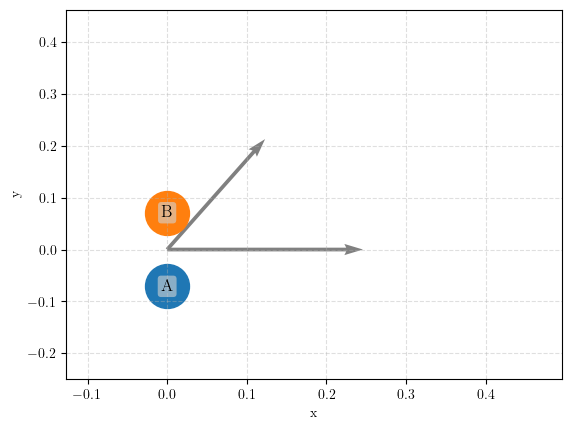

In [2]:
m=1
a = 0.24595   # [nm] unit cell length
a_cc = 0.142  # [nm] carbon-carbon distance
t=-2.7
lat=jpb.Lattice(a1=[a, 0],a2=[a/2, a/2 * np.sqrt(3)])

lat.add_sublattices(('A', [0, -a_cc/2],m),
                    ('B', [0,  a_cc/2],-m)
)

lat.add_hoppings(
    # inside the main cell
    ([0,  0], 'A', 'B', t),
    # between neighboring cells
    ([1, -1], 'A', 'B', t),
    ([0, -1], 'A', 'B', t)
)



lat.plot()



In [3]:
model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)


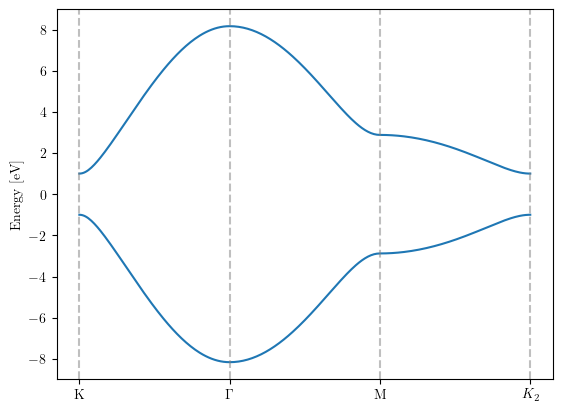

In [4]:
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc), 0]
M = [0, 2*np.pi / (3*a_cc)]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc), 2*np.pi / (3*a_cc)]

k_points=[K1,Gamma,M,K2]

ene_mat=solver.calc_bands(k_points,True,[r'K',r'$\Gamma$',r'M',r'$K_2$'])



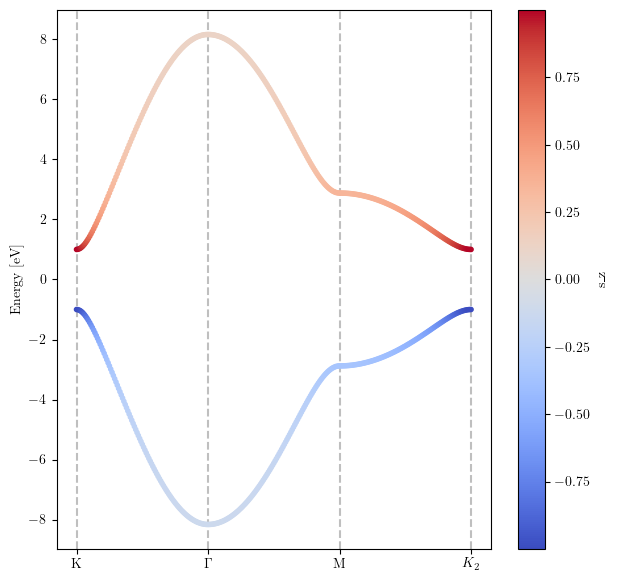

In [5]:
sigma_z=np.array([[1,0],[0,-1]])
pol,_=solver.calc_polarization([sigma_z],300,True,['s_z'])

# print(pol)

# With multiorbital model

In [6]:
def Slater_Koaster_s_px_py_pz(e,Vsss,Vsps,Vpps,Vppp):

    ### Vector normalization
    e_norm=e/np.linalg.norm(e)

    ### Building the matrix
    t_mat=np.zeros((4,4),dtype=complex)
    
    ### s-s
    t_mat[0,0]=Vsss
    ### s-p
    # s-px hopping
    t_mat[0,1]=e_norm[0]*Vsps
    t_mat[1,0]=-e_norm[0]*Vsps
    # s-py hopping
    t_mat[0,2]=e_norm[1]*Vsps
    t_mat[2,0]=-e_norm[1]*Vsps
    # s-pz hopping
    t_mat[0,3]=e_norm[2]*Vsps
    t_mat[3,0]=-e_norm[2]*Vsps
            
    ### p-p


    # px-px hopping
    t_mat[1,1]=(e_norm[0]**2*Vpps+(1-e_norm[0]**2)*Vppp)
    # px-py hopping
    t_mat[1,2]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # px-pz hopping
    t_mat[1,3]=e_norm[0]*e_norm[2]*(Vpps-Vppp)

    # py-py hopping
    t_mat[2,2]=(e_norm[1]**2*Vpps+(1-e_norm[1]**2)*Vppp)
    # py-px hopping
    t_mat[2,1]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # py-pz hopping
    t_mat[2,3]=e_norm[1]*e_norm[2]*(Vpps-Vppp)
    
    # pz-pz hopping
    t_mat[3,3]=(e_norm[2]**2*Vpps+(1-e_norm[2]**2)*Vppp)
    # pz-px hopping
    t_mat[3,1]=e_norm[0]*e_norm[2]*(Vpps-Vppp)
    # pz-py hopping
    t_mat[3,2]=e_norm[1]*e_norm[2]*(Vpps-Vppp)


    return t_mat


def pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=0.5,Vsps=0.5,Vpps=0.5,Vppp=0.2,lambda_SOC=0.1):
    """
    Default parameters are extracted from : https://doi.org/10.1103/PhysRevLett.121.086602

    """

    
    d = 2  # [A] unit cell length
    pos_A=np.array([0, 0,0])
    a1=np.array([d, 0,0])
    a2=np.array([0, d,0])
    onsites=np.diag([Es,Ep,Ep,Ep])
    # SOC part
    Lx=np.array([[0,0,0,0],[0,0,0,0],[0,0,0,-1j],[0,0,1j,0]])
    Ly=np.array([[0,0,0,0],[0,0,0,1j],[0,0,0,0],[0,-1j,0,0]])
    Lz=np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]])

    Sx=0.5*np.array([[0,1],[1,0]])
    Sy=0.5*np.array([[0,-1j],[1j,0]])
    Sz=0.5*np.array([[1,0],[0,-1]])
    L_S=2*lambda_SOC*(np.kron(Lx,Sx)+np.kron(Ly,Sy)+np.kron(Lz,Sz))

    

    # print(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    # print(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    
    # create a simple 2D lattice with vectors a1 and a2
    lattice = jpb.Lattice(a1, a2)
    lattice.add_sublattices(
        ('A', pos_A ,np.kron(onsites,np.eye(2))+L_S),  # add an atom called 'A' at position [0, 0]
    )
    lattice.add_hoppings(
        # (relative_index, from_sublattice, to_sublattice, energy)
        ## Same lattice
        ([1, 0], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))),
        ([0, 1], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))), 
 )
    

    return lattice


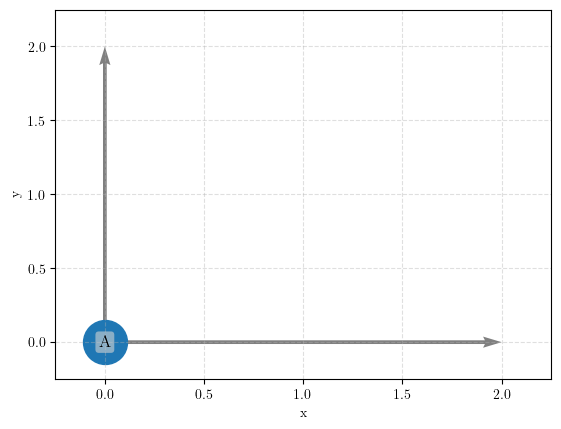

In [7]:
lat=pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=-0.5,Vsps=0.5,Vpps=0.5,Vppp=-0.2,lambda_SOC=0.05)
lat.plot()

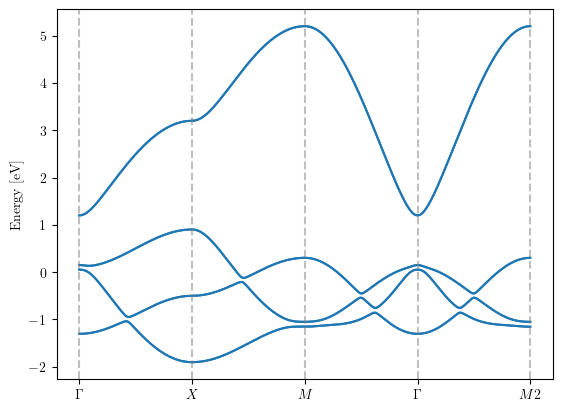

In [8]:

model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)
Gamma=[0,0,0]
X=[np.pi/2,0,0]
M=[np.pi/2,np.pi/2,0]
M2=[-np.pi/2,np.pi/2,0]
Y=[0,np.pi/2,0]

k_points_labels=[r'$\Gamma$',r'$X$',r'$M$',r'$\Gamma$',r'$M2$']
k_points=[Gamma,X,M,Gamma,M2]

ene_mat=solver.calc_bands(k_points,True,k_points_labels)



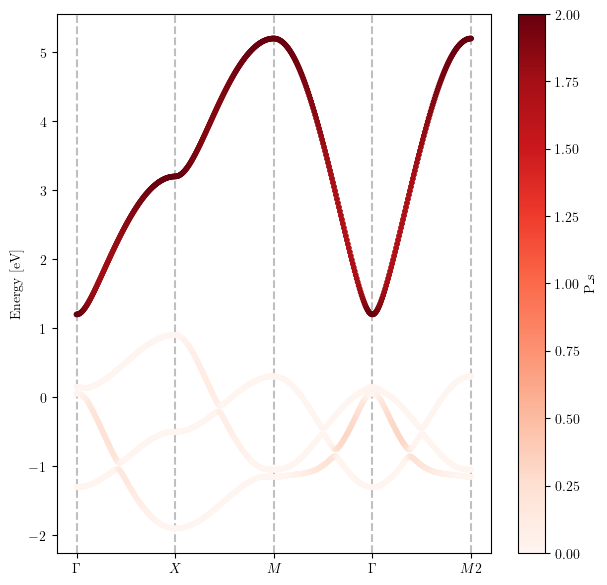

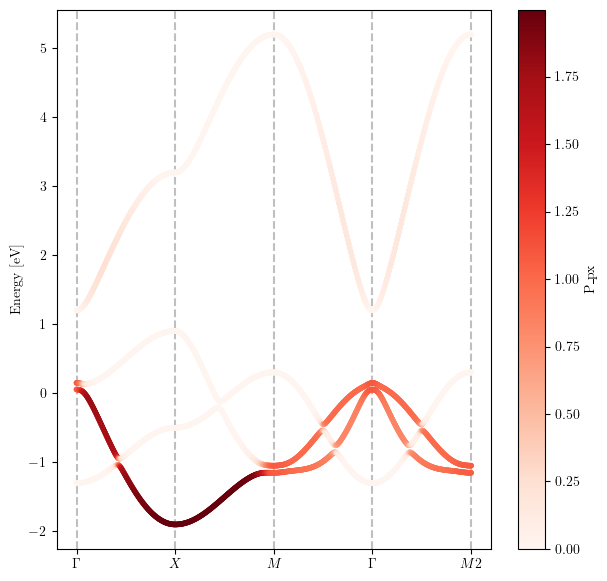

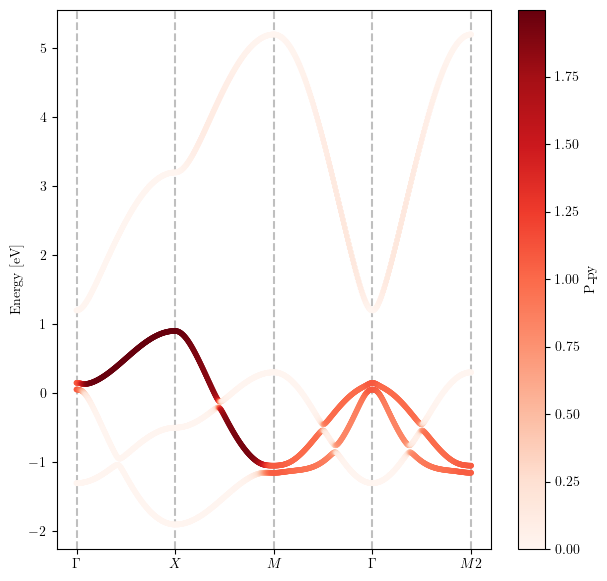

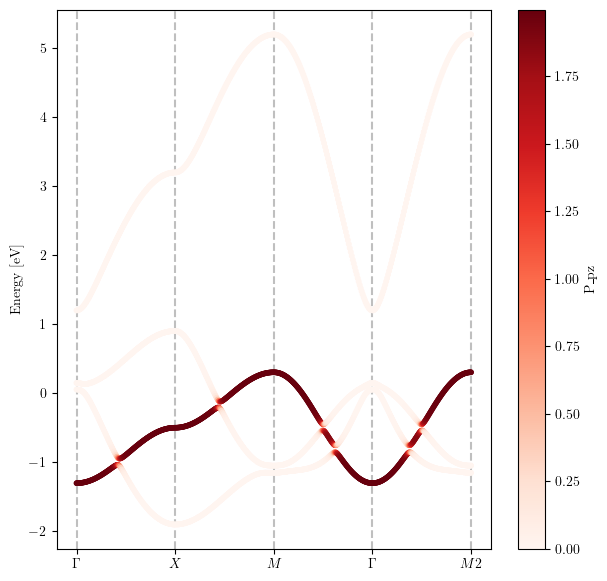

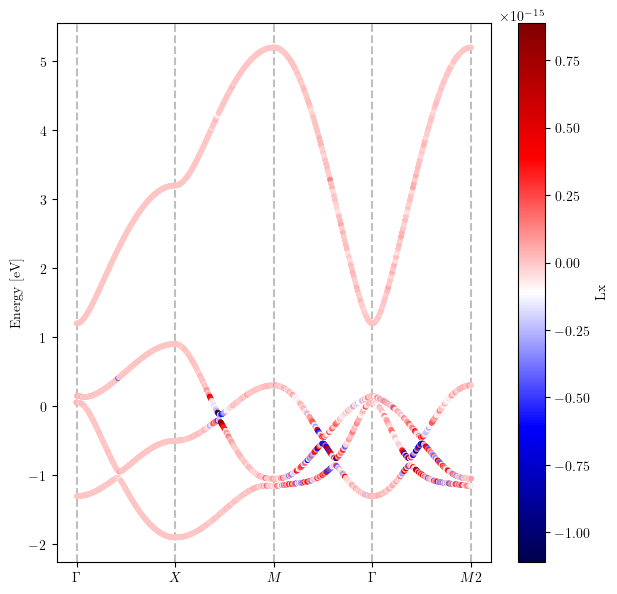

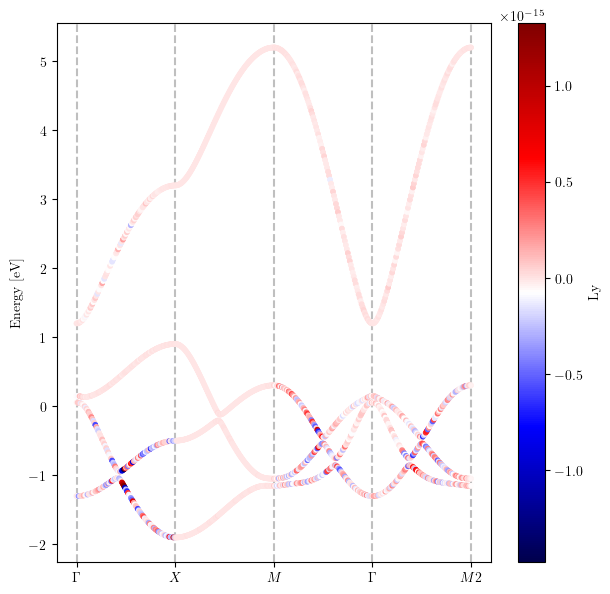

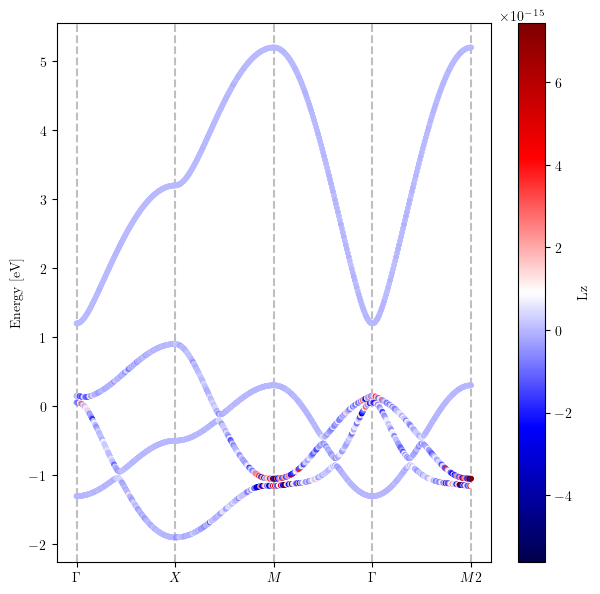

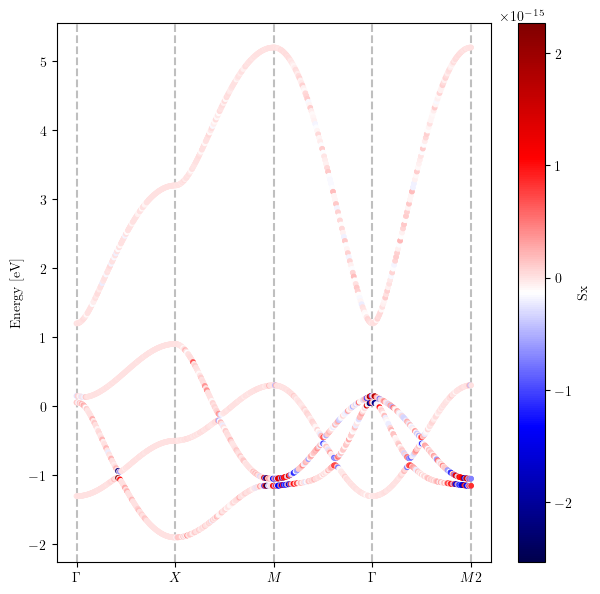

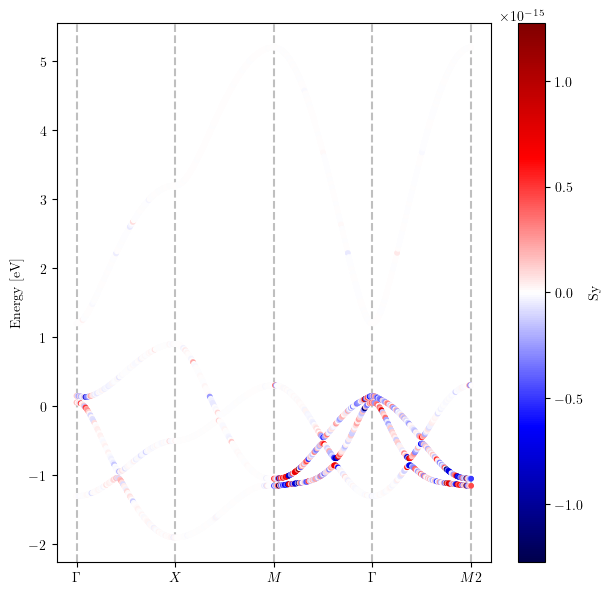

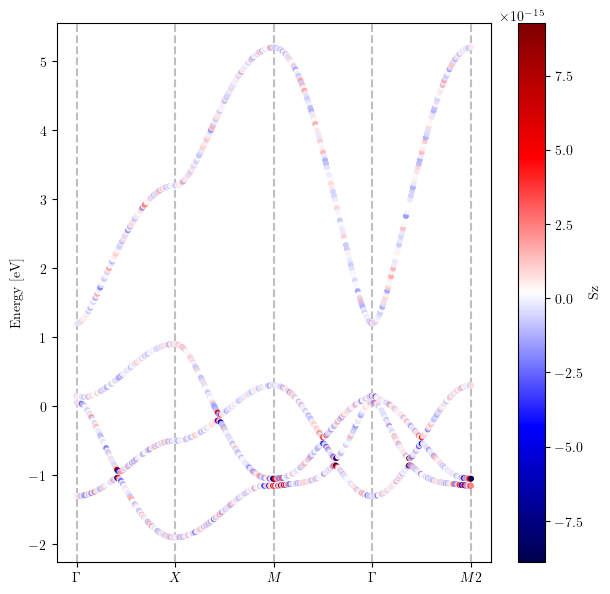

In [9]:
operator_label_list=['P_s','P_px','P_py','P_pz','Lx','Ly','Lz','Sx','Sy','Sz']
P_ss=np.kron(np.diag([1,0,0,0]),np.eye(2))
P_px=np.kron(np.diag([0,1,0,0]),np.eye(2))
P_py=np.kron(np.diag([0,0,1,0]),np.eye(2))
P_pz=np.kron(np.diag([0,0,0,1]),np.eye(2))
Lx=np.kron(np.array([[0,0,0,0],[0,0,0,0],[0,0,0,-1j],[0,0,1j,0]]),np.eye(2))
Ly=np.kron(np.array([[0,0,0,0],[0,0,0,1j],[0,0,0,0],[0,-1j,0,0]]),np.eye(2))
Lz=np.kron(np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]]),np.eye(2))
Sx=np.kron(np.eye(4),np.array([[0,1],[1,0]]))
Sy=np.kron(np.eye(4),np.array([[0,-1j],[1j,0]]))
Sz=np.kron(np.eye(4),np.array([[1,0],[0,-1]]))
operator_list=[P_ss,P_px,P_py,P_pz,Lx,Ly,Lz,Sx,Sy,Sz]
colorbar_list=['Reds','Reds','Reds','Reds','seismic','seismic','seismic','seismic','seismic','seismic']
pol,_=solver.calc_polarization(operator_list,300,True,operator_label_list,colorbar_list)
